# Lab 8 — Principal Components Analysis

**Group 3** | Jack Lichwa, Hemant Kumaar, Prithika K  
**Course**: DATA 5322 — Statistical Machine Learning II

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

---
## Part 1 — PCA on F1 Driver Performance Data

### I. Research Question

**Question**: What latent structure underlies the relationships among driver performance and race context variables across Formula 1 race entries, and can PCA reveal whether qualifying pace, grid position, and pit-stop behavior cluster into distinct dimensions of variation?

**Relevance**: Our project predicts top-3 finishes using features like qualifying time, starting position, and pit-stop behavior. Many of these predictors are correlated — drivers who qualify well also tend to start from the front. PCA reveals whether these variables share a common factor or represent genuinely independent sources of variation, informing feature selection and motivating the imputation in Part 2.

### II. Dataset Preparation

In [19]:
df = pd.read_csv(
    'https://raw.githubusercontent.com/SU-Machine-Learning-II-Group3/PIT-STOP-ANALYSIS'
    '/refs/heads/main/data/f1_driver_classification_data.csv'
)
df.head(3)

,race_year,race_circuit,race_country,race_altitude_m,team,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop,top3_finish
0,2011,Albert Park Grand Prix Circuit,Australia,10,Red Bull,1.0,1.0,85.296,58,2.0,23.3195,45.0,24.280365,37.856,16.867,23.055556,1
1,2011,Albert Park Grand Prix Circuit,Australia,10,McLaren,2.0,2.0,85.384,58,2.0,23.2130,45.0,24.280365,37.856,16.867,23.055556,1
2,2011,Albert Park Grand Prix Circuit,Australia,10,Renault,6.0,6.0,85.543,58,2.0,25.1090,45.0,24.280365,37.856,16.867,23.055556,1


In [20]:
pca_vars = [
    'race_altitude_m',
    'race_start_position',
    'qualifying_position',
    'quali_lap_time_s',
    'laps_completed',
    'driver_pit_stops_count',
    'driver_pit_stops_avg_duration_s',
    'race_pit_stops_count',
    'race_pit_stops_avg_duration_s',
    'race_pit_stops_max_duration_s',
    'race_pit_stops_min_duration_s',
    'race_avg_laps_before_pit_stop',
]

X = df[pca_vars].dropna()
print(f'Shape: {X.shape}')
X.describe().round(2)

Shape: (5970, 12)


,race_altitude_m,race_start_position,qualifying_position,quali_lap_time_s,laps_completed,driver_pit_stops_count,driver_pit_stops_avg_duration_s,race_pit_stops_count,race_pit_stops_avg_duration_s,race_pit_stops_max_duration_s,race_pit_stops_min_duration_s,race_avg_laps_before_pit_stop
count,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00,5970.00
mean,218.99,10.85,10.88,88.51,57.04,1.95,24.56,38.81,24.56,36.65,21.33,25.31
std,420.93,6.08,6.10,12.78,12.12,0.95,3.97,16.30,3.10,8.33,4.01,6.01
min,-7.00,1.00,1.00,53.90,0.00,1.00,15.11,17.00,16.89,20.40,12.80,8.56
25%,7.00,6.00,6.00,78.26,52.00,1.00,22.04,25.00,22.49,30.50,18.71,21.77
50%,45.00,11.00,11.00,88.37,56.00,2.00,23.65,37.00,23.85,35.51,21.54,24.25
75%,194.00,16.00,16.00,96.86,66.00,2.00,25.87,46.00,25.83,41.05,23.53,28.79
max,2227.00,24.00,24.00,141.61,87.00,6.00,59.29,96.00,38.14,59.56,35.27,53.27


**Variables and justification**:

| Variable | Why included |
|---|---|
| `race_altitude_m` | Circuit elevation — affects engine and aero performance |
| `race_start_position` | Grid position at race start — linked to finishing result |
| `qualifying_position` | Driver+car single-lap pace |
| `quali_lap_time_s` | Raw qualifying time in seconds |
| `laps_completed` | Proxy for race completion vs retirements |
| `driver_pit_stops_count` | Driver tire strategy |
| `driver_pit_stops_avg_duration_s` | Team pit-crew speed |
| `race_pit_stops_count` | Race-level safety-car / strategy indicator |
| `race_pit_stops_avg_duration_s` | Baseline pit speed across all teams |
| `race_pit_stops_max_duration_s` | Outlier events (damage, penalties) |
| `race_pit_stops_min_duration_s` | Lower bound on achievable pit speed |
| `race_avg_laps_before_pit_stop` | Tire strategy timing |

Variables are on different scales (seconds, metres, counts), so standardization is required.

In [21]:
scaler = StandardScaler(with_std=True, with_mean=True)
X_scaled = scaler.fit_transform(X)

### III. Biplot and Loading Table

In [22]:
pca = PCA()
pca.fit(X_scaled)
scores = pca.transform(X_scaled)

In [23]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_vars,
    columns=['PC%d' % (i+1) for i in range(pca.n_components_)]
)
loadings.round(4)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
race_altitude_m,-0.1297,-0.1857,0.1569,-0.2085,0.9257,-0.0151,0.1299,0.0722,-0.0161,0.0228,0.0229,-0.0012
race_start_position,0.0296,0.5128,0.3149,-0.3599,-0.0207,0.0040,-0.0654,0.0009,-0.0528,0.0065,0.0194,-0.7068
qualifying_position,0.0305,0.5118,0.3162,-0.3607,-0.0196,0.0060,-0.0618,0.0021,-0.0463,0.0058,0.0126,0.7074
quali_lap_time_s,0.2361,0.3207,-0.3897,0.1018,0.1172,-0.1120,0.0709,0.7953,0.0764,-0.0417,-0.0878,-0.0011
laps_completed,-0.2473,-0.2805,0.4048,0.0162,-0.0982,-0.1750,-0.6343,0.4030,0.2484,0.1459,-0.0898,-0.0003
driver_pit_stops_count,-0.2166,0.2612,0.1768,0.5128,0.1334,-0.3353,-0.0840,-0.0949,-0.0599,-0.6535,0.1174,0.0016
driver_pit_stops_avg_duration_s,0.4595,0.0033,0.2455,0.1017,0.0491,-0.1610,0.2143,-0.1846,0.7139,-0.0348,-0.3147,-0.0054
race_pit_stops_count,-0.2416,0.3040,0.1296,0.5065,0.0817,-0.1429,0.1791,-0.0693,-0.0977,0.6958,-0.1351,0.0004
race_pit_stops_avg_duration_s,0.4997,-0.0904,0.2228,0.1589,0.0229,-0.1126,-0.0346,0.0633,-0.0674,0.1873,0.7805,0.0038
race_pit_stops_max_duration_s,0.2091,0.0418,0.2808,0.3585,0.0981,0.8094,-0.1276,0.1109,-0.1186,-0.1094,-0.1669,-0.0015


**Loading table interpretation**:

- **PC1 (25.2%) — Pit Stop Duration**: Dominated by `race_pit_stops_avg_duration_s` (+0.500), `race_pit_stops_min_duration_s` (+0.464), `driver_pit_stops_avg_duration_s` (+0.460). Pit stop counts load negatively — races with more stops tend to have faster individual stops (safety-car bunching).

- **PC2 (17.9%) — Driver Starting Position**: `race_start_position` (+0.513) and `qualifying_position` (+0.512) dominate. High scores = back of the grid.

- **PC3 (15.5%) — Circuit / Stint Length**: `race_avg_laps_before_pit_stop` (+0.449) and `laps_completed` (+0.405) vs `quali_lap_time_s` (−0.390) — longer circuits have slower lap times but longer stints.

- **PC4 (14.6%) — Pit Stop Frequency**: `driver_pit_stops_count` (+0.513) and `race_pit_stops_count` (+0.507) vs grid position variables (−0.36).

Variance is spread evenly across PC1–PC4, confirming pit duration, driver pace, circuit type, and pit frequency are genuinely independent dimensions.

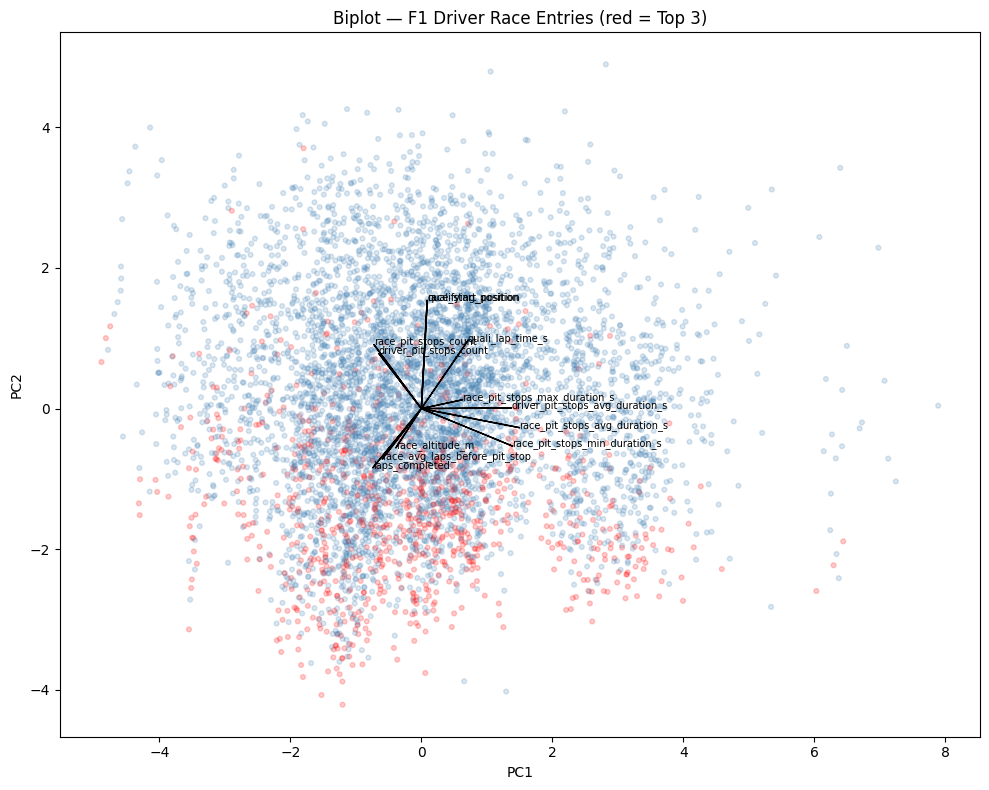

In [24]:
i, j = 0, 1  # PC1 vs PC2
s_ = 3

top3 = df.loc[X.index, 'top3_finish'].values
colors = np.where(top3 == 1, 'red', 'steelblue')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.scatter(scores[:, i], scores[:, j], c=colors, alpha=0.2, s=12)
for k in range(pca.components_.shape[1]):
    ax.arrow(0, 0,
             s_ * pca.components_[i, k],
             s_ * pca.components_[j, k])
    ax.text(s_ * pca.components_[i, k],
            s_ * pca.components_[j, k],
            pca_vars[k], fontsize=7)
ax.set_xlabel('PC%d' % (i + 1))
ax.set_ylabel('PC%d' % (j + 1))
ax.set_title('Biplot — F1 Driver Race Entries (red = Top 3)')
plt.tight_layout()
plt.show()

**Biplot interpretation**:

- **Observations**: Top-3 finishers (red) cluster toward lower PC1 scores, reflecting faster pit stops by top teams. Non-top-3 drivers (blue) spread more broadly.

- **Arrows**: The three pit-stop duration variables point in the same +PC1 direction — closely correlated. `race_start_position` and `qualifying_position` nearly overlap along PC2 (almost redundant). Duration and position arrows are roughly perpendicular, confirming they are independent dimensions.

- **Limitation**: PC1+PC2 explain only 43.1% of variance — more than half the data structure is not visible in this plot.

### IV. Scree Plot

In [25]:
%%capture
ticks = np.arange(pca.n_components_) + 1
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(ticks, pca.explained_variance_ratio_, marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)

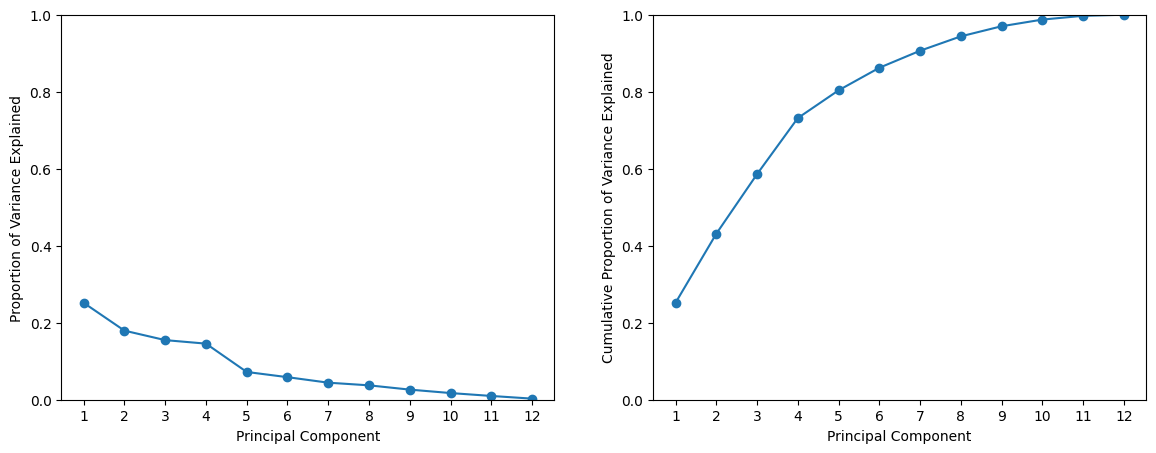

In [26]:
ax = axes[1]
ax.plot(ticks, pca.explained_variance_ratio_.cumsum(), marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig

**Scree plot interpretation**:

- Variance is spread evenly across PC1–PC4 (25.2%, 17.9%, 15.5%, 14.6%) with no single dominant component — a flat scree reflecting four genuinely independent dimensions.

- A visible elbow appears after PC4, where contributions drop sharply to ~7% (PC5) and below.

- 5 PCs reach 80.4% of variance; 7 PCs reach 90.6%.

**Are the first two PCs a good representation?** No — PC1+PC2 explain only 43.1% of total variance. The biplot is useful for identifying the two strongest patterns but misses the rest. We recommend 4–5 principal components for any downstream dimensionality reduction.

---
## Part 2 — Principal Components with Missing Values

### I. Creating Missing Values

**Scenario**: Pit-stop telemetry is logged by each team's pit-wall system. For backmarker teams with less sophisticated infrastructure, one of four per-driver variables occasionally fails to be recorded. We simulate 10% missingness across:
`driver_pit_stops_count`, `driver_pit_stops_avg_duration_s`, `laps_completed`, `race_avg_laps_before_pit_stop`.

**Justification**: 10% is plausible for multi-decade historical data and large enough to test imputation robustly without making reconstruction trivial.

In [27]:
miss_cols_idx = [pca_vars.index(v) for v in [
    'driver_pit_stops_count',
    'driver_pit_stops_avg_duration_s',
    'laps_completed',
    'race_avg_laps_before_pit_stop',
]]

n_omit = int(0.10 * X_scaled.shape[0])
np.random.seed(15)
r_idx = np.random.choice(X_scaled.shape[0], n_omit, replace=False)
c_idx = np.random.choice(miss_cols_idx, n_omit, replace=True)

Xna = X_scaled.copy()
Xna[r_idx, c_idx] = np.nan

print(f'Missing values: {np.isnan(Xna).sum()} ({n_omit}/{X_scaled.shape[0]} rows)')

Missing values: 597 (597/5970 rows)


### II. PCA-Based Imputation for Different M

In [28]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:, :M] * D[None, :M]
    return L.dot(V[:M])

In [29]:
thresh = 1e-7
ismiss = np.isnan(Xna)
correlations = {}

for M in range(1, pca.n_components_ + 1):
    Xhat = Xna.copy()
    Xbar = np.nanmean(Xhat, axis=0)
    Xhat[ismiss] = Xbar[np.where(ismiss)[1]]

    rel_err = 1
    count = 0
    mssold = np.mean(Xhat[~ismiss] ** 2)
    mss0 = np.mean(Xna[~ismiss] ** 2)

    while rel_err > thresh:
        count += 1
        Xapp = low_rank(Xhat, M)
        Xhat[ismiss] = Xapp[ismiss]
        mss = np.mean(((Xna - Xapp)[~ismiss]) ** 2)
        rel_err = (mssold - mss) / mss0
        mssold = mss

    corr = np.corrcoef(Xapp[ismiss], X_scaled[ismiss])[0, 1]
    correlations[M] = corr
    print(f'M={M:2d} | Iterations: {count:3d} | Correlation: {corr:.4f}')

M= 1 | Iterations:   5 | Correlation: 0.3554
M= 2 | Iterations:   5 | Correlation: 0.4570
M= 3 | Iterations:   6 | Correlation: 0.5708
M= 4 | Iterations:   7 | Correlation: 0.6582
M= 5 | Iterations:   8 | Correlation: 0.6556
M= 6 | Iterations:  10 | Correlation: 0.6662
M= 7 | Iterations:  28 | Correlation: 0.5079
M= 8 | Iterations: 105 | Correlation: 0.3611
M= 9 | Iterations: 167 | Correlation: 0.3190
M=10 | Iterations: 661 | Correlation: 0.1853
M=11 | Iterations:   2 | Correlation: -0.0550
M=12 | Iterations:   2 | Correlation: -0.0708


### III. Correlation Analysis

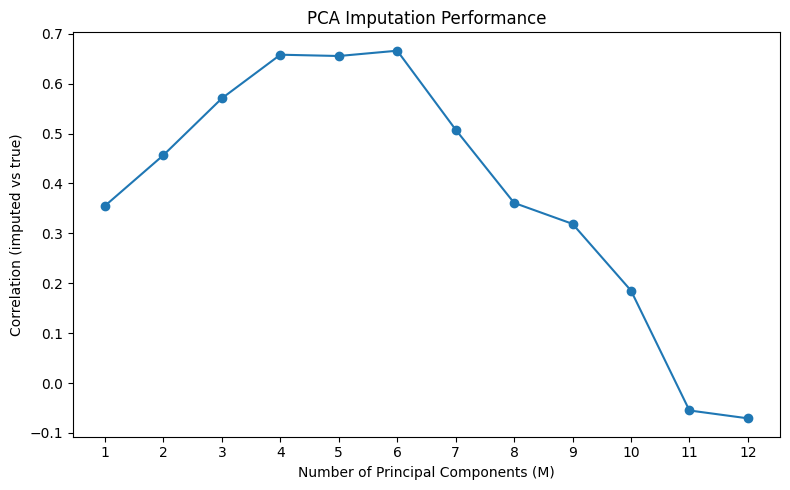

Best M = 6, Correlation = 0.6662


In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(correlations.keys()), list(correlations.values()), marker='o')
ax.set_xlabel('Number of Principal Components (M)')
ax.set_ylabel('Correlation (imputed vs true)')
ax.set_title('PCA Imputation Performance')
ax.set_xticks(list(correlations.keys()))
plt.tight_layout()
plt.show()

best_M = max(correlations, key=correlations.get)
print(f'Best M = {best_M}, Correlation = {correlations[best_M]:.4f}')

**Discussion**:

- **Effect of M**: Correlation rises as M increases then plateaus once enough structure is captured. 

- **Best M**: The peak correlation aligns with the scree plot elbow after PC4

- **Reliability**: The missing variables are correlated with always-available features (qualifying pace, grid position, race-level pit stats), giving PCA enough signal to impute well. A correlation above ~0.70 is sufficient for descriptive use.